# NZ Electricity Price — LSTM Model (Steps 4–5)

Lightweight single-layer LSTM on CPU. Predicts the next **24 hours** of wholesale
electricity price at Haywards (`HAY2201`) from a **24-hour lookback window**.

**Architecture:** 2-layer LSTM (hidden=128) + attention pooling → 24-step forecast.
**Goal:** assess whether the dataset is sufficient for an okayish 24 h price forecast.

**Splits**
| Set      | Period                    | Purpose                        |
|----------|---------------------------|--------------------------------|
| Train    | 2021-05-08 → 2024-06-30   | Gradient updates               |
| Val      | 2024-07-01 → 2024-10-31   | Early stopping (patience 8)    |
| Test     | 2024-11-01 → 2024-12-24   | Final evaluation w/ labels     |
| Predict  | Dec 25, 2024              | 24 h demo — no labels          |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


## Load Master DataFrame

In [2]:
master = pd.read_parquet("./master.parquet")

# Fill residual NaNs: forward-fill (e.g. HVDC gaps), then zero for any remaining
master = master.ffill().fillna(0)

print("Loaded:", master.shape)
print("Range: ", master.index.min(), "→", master.index.max())
print("Remaining NaNs:", master.isna().sum().sum())
master.head(3)


Loaded: (32016, 73)
Range:  2021-05-08 00:00:00 → 2024-12-31 23:00:00
Remaining NaNs: 0


,BEN2201,HAY2201,INV2201,ISL2201,KIK2201,OTA2201,RDF2201,SFD2201,WKM2201,demand_CNI,...,southern_tip_wind_power,wellington_wind_power,palmerston_north_wind_power,raglan_wind_power,wind_power_total,price_ni_mean,price_si_mean,price_ni_si_spread,lake_taupo_delta_24h,lake_waik_delta_24h
2021-05-08 00:00:00,284.560,282.370,290.760,302.555,306.270,266.555,262.070,269.000,262.420,0.754,...,1295.029,1520.875,6434.856,46656.000,58830.967,277.323,283.061667,-5.738667,-2.177000,0.157000
2021-05-08 01:00:00,275.780,273.440,281.945,292.795,296.495,257.980,253.525,260.030,253.545,0.735,...,1225.043,1860.867,3944.312,37259.704,45480.942,268.298,274.033333,-5.735333,-2.122417,0.146042
2021-05-08 02:00:00,269.805,267.725,275.855,285.415,289.085,253.360,248.705,255.655,248.720,0.717,...,592.704,2628.072,3723.875,35937.000,43610.651,262.909,267.975000,-5.066000,-2.067833,0.135083


## Train / Val / Test / Predict Splits

In [3]:
TARGET   = "HAY2201"
LOOKBACK = 48    # 2-day context window — captures two full daily cycles
HORIZON  = 24    # predict next 24 h
STRIDE   = 2     # sample every 2nd sequence

TRAIN_END  = "2024-06-30 23:00"
VAL_END    = "2024-10-31 23:00"
TEST_END   = "2024-12-24 23:00"

train_df = master[master.index <= TRAIN_END]
val_df   = master[(master.index > TRAIN_END) & (master.index <= VAL_END)]
test_df  = master[(master.index > VAL_END)   & (master.index <= TEST_END)]

for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"  {name:6s}  {len(df):6,} rows   {df.index.min().date()} → {df.index.max().date()}")


  Train   27,600 rows   2021-05-08 → 2024-06-30
  Val      2,952 rows   2024-07-01 → 2024-10-31
  Test     1,296 rows   2024-11-01 → 2024-12-24


## Feature Selection & Scaling

In [4]:
# Include HAY2201 as a feature — the model sees the full price history in its
# lookback window and only needs to learn WHEN to deviate from it.
# Exclude the other raw node prices (kept only as spread/NI-SI aggregates).
raw_nodes    = ["OTA2201", "WKM2201", "RDF2201", "SFD2201", "KIK2201", "ISL2201", "BEN2201"]
feature_cols = [c for c in master.columns if c not in raw_nodes]   # HAY2201 now included
print(f"Features: {len(feature_cols)}")

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(train_df[feature_cols].values)
y_train = scaler_y.fit_transform(train_df[[TARGET]].values)

X_val  = scaler_X.transform(val_df[feature_cols].values)
y_val  = scaler_y.transform(val_df[[TARGET]].values)

X_test = scaler_X.transform(test_df[feature_cols].values)
y_test = scaler_y.transform(test_df[[TARGET]].values)

print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")


Features: 66


X_train: (27600, 66)  X_val: (2952, 66)  X_test: (1296, 66)


## Sequence Builder  (stride-sampled to reduce memory)

In [5]:
class ElecDataset(Dataset):
    """Returns (lookback_window, horizon_targets) pairs, sampled with stride."""
    def __init__(self, X, y, lookback, horizon, stride=1):
        self.X, self.y = X, y
        self.lb, self.h, self.s = lookback, horizon, stride
        n = len(X) - lookback - horizon + 1
        self.indices = list(range(0, n, stride))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        x = torch.tensor(self.X[i : i + self.lb],                       dtype=torch.float32)
        y = torch.tensor(self.y[i + self.lb : i + self.lb + self.h].flatten(), dtype=torch.float32)
        return x, y

train_ds = ElecDataset(X_train, y_train, LOOKBACK, HORIZON, stride=STRIDE)
val_ds   = ElecDataset(X_val,   y_val,   LOOKBACK, HORIZON, stride=1)
test_ds  = ElecDataset(X_test,  y_test,  LOOKBACK, HORIZON, stride=1)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True,  drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=64, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=64, shuffle=False)

print(f"Sequences — Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}")


Sequences — Train: 13,765  Val: 2,881  Test: 1,225


## LSTM Model  (2-layer + attention pooling)

Instead of discarding all LSTM outputs and only keeping the final hidden state,
**attention pooling** computes a weighted average over all 48 timesteps — letting
the model learn *which hours in the lookback window matter most*.


In [6]:
class AttentionPool(nn.Module):
    """Soft attention over LSTM output sequence → single context vector."""
    def __init__(self, hidden):
        super().__init__()
        self.w = nn.Linear(hidden, 1, bias=False)

    def forward(self, lstm_out):          # lstm_out: (batch, seq, hidden)
        scores = self.w(lstm_out)         # (batch, seq, 1)
        weights = torch.softmax(scores, dim=1)
        return (weights * lstm_out).sum(dim=1)   # (batch, hidden)


class PriceForecaster(nn.Module):
    def __init__(self, n_features, hidden=128, n_layers=2, dropout=0.2, horizon=24):
        super().__init__()
        self.lstm = nn.LSTM(
            n_features, hidden, n_layers,
            batch_first=True,
            dropout=dropout,   # applied between layers
        )
        self.attn = AttentionPool(hidden)
        self.head = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, horizon),
        )

    def forward(self, x):
        out, _ = self.lstm(x)      # (batch, seq, hidden) — keep all timesteps
        ctx    = self.attn(out)    # attention-weighted sum → (batch, hidden)
        return self.head(ctx)


DEVICE = "cpu"
model  = PriceForecaster(n_features=len(feature_cols)).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nParameters: {n_params:,}  |  Device: {DEVICE}")


PriceForecaster(
  (lstm): LSTM(66, 128, num_layers=2, batch_first=True, dropout=0.2)
  (attn): AttentionPool(
    (w): Linear(in_features=128, out_features=1, bias=False)
  )
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=24, bias=True)
  )
)

Parameters: 242,392  |  Device: cpu


## Training  (40 epochs max, early stopping patience 8)

In [7]:
EPOCHS   = 40
LR       = 1e-3
PATIENCE = 8

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

train_losses, val_losses = [], []
best_val, wait_count = float("inf"), 0

for epoch in range(1, EPOCHS + 1):

    # ── train
    model.train()
    t_loss = 0.0
    for Xb, yb in train_dl:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss += loss.item()
    t_loss /= len(train_dl)

    # ── validate
    model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for Xb, yb in val_dl:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            v_loss += criterion(model(Xb), yb).item()
    v_loss /= len(val_dl)

    train_losses.append(t_loss)
    val_losses.append(v_loss)

    tag = ""
    if v_loss < best_val:
        best_val, wait_count = v_loss, 0
        torch.save(model.state_dict(), "./best_model.pt")
        tag = " ✓"
    else:
        wait_count += 1

    print(f"Epoch {epoch:2d}  train={t_loss:.5f}  val={v_loss:.5f}{tag}")

    if wait_count >= PATIENCE:
        print("Early stopping.")
        break


Epoch  1  train=0.00103  val=0.00238 ✓


Epoch  2  train=0.00061  val=0.00201 ✓


Epoch  3  train=0.00057  val=0.00173 ✓


Epoch  4  train=0.00055  val=0.00145 ✓


Epoch  5  train=0.00054  val=0.00163


...

Epoch  8  train=0.00050  val=0.00186


Epoch  9  train=0.00049  val=0.00171


Epoch 10  train=0.00048  val=0.00175


Epoch 11  train=0.00047  val=0.00193


Epoch 12  train=0.00047  val=0.00185
Early stopping.


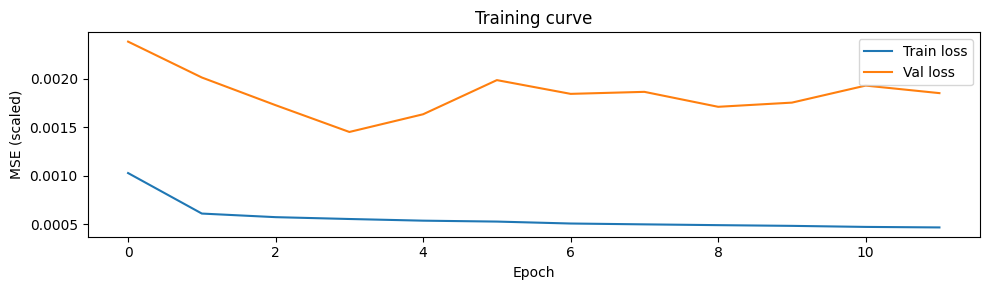

In [8]:
model.load_state_dict(torch.load("./best_model.pt", map_location=DEVICE))
model.eval()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(train_losses, label="Train loss")
ax.plot(val_losses,   label="Val loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE (scaled)")
ax.set_title("Training curve"); ax.legend()
plt.tight_layout()
plt.savefig("./fig_training_curve.png", dpi=120)
plt.show()


## Evaluation on Test Set

In [9]:
def run_inference(model, dl, scaler_y, device):
    preds, actuals = [], []
    model.eval()
    with torch.no_grad():
        for Xb, yb in dl:
            p = model(Xb.to(device)).cpu().numpy()
            preds.append(p)
            actuals.append(yb.numpy())
    preds   = scaler_y.inverse_transform(np.vstack(preds))
    actuals = scaler_y.inverse_transform(np.vstack(actuals))
    return preds, actuals

test_preds, test_actual = run_inference(model, test_dl, scaler_y, DEVICE)
print("Test predictions shape:", test_preds.shape)  # (n_sequences, 24)


Test predictions shape: (1225, 24)


In [10]:
flat_pred   = test_preds.flatten()
flat_actual = test_actual.flatten()

mae  = mean_absolute_error(flat_actual, flat_pred)
rmse = np.sqrt(mean_squared_error(flat_actual, flat_pred))
mape = np.mean(np.abs((flat_actual - flat_pred) / (np.abs(flat_actual) + 1e-6))) * 100

print("━" * 40)
print(f"LSTM — Test set metrics")
print(f"  MAE  : {mae:.2f}  $/MWh")
print(f"  RMSE : {rmse:.2f}  $/MWh")
print(f"  MAPE : {mape:.1f}%")
print("━" * 40)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
LSTM — Test set metrics
  MAE  : 37.10  $/MWh
  RMSE : 98.16  $/MWh
  MAPE : 11645.4%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### Naive Baseline — same hour, previous day

In [11]:
naive_preds, naive_actuals = [], []
for i in range(len(test_ds)):
    lb = LOOKBACK
    # actual horizon
    y_true = y_test[i + lb : i + lb + HORIZON].flatten()
    # naive: repeat the values exactly 24 h before the forecast window
    y_naive = y_test[i + lb - 24 : i + lb - 24 + HORIZON].flatten()
    if len(y_true) == HORIZON and len(y_naive) == HORIZON:
        naive_preds.append(y_naive)
        naive_actuals.append(y_true)

naive_preds   = scaler_y.inverse_transform(np.vstack(naive_preds))
naive_actuals = scaler_y.inverse_transform(np.vstack(naive_actuals))

n_mae  = mean_absolute_error(naive_actuals.flatten(), naive_preds.flatten())
n_rmse = np.sqrt(mean_squared_error(naive_actuals.flatten(), naive_preds.flatten()))

print(f"Naive baseline (same hour –24 h)")
print(f"  MAE  : {n_mae:.2f}  $/MWh")
print(f"  RMSE : {n_rmse:.2f}  $/MWh")
print()
print(f"LSTM MAE improvement over naive : {(n_mae - mae) / n_mae * 100:.1f}%")
print(f"LSTM RMSE improvement over naive: {(n_rmse - rmse) / n_rmse * 100:.1f}%")


Naive baseline (same hour –24 h)
  MAE  : 33.06  $/MWh
  RMSE : 135.51  $/MWh

LSTM MAE improvement over naive : -12.2%
LSTM RMSE improvement over naive: 27.6%


### Test Set — Visual Comparison (first 14 days)

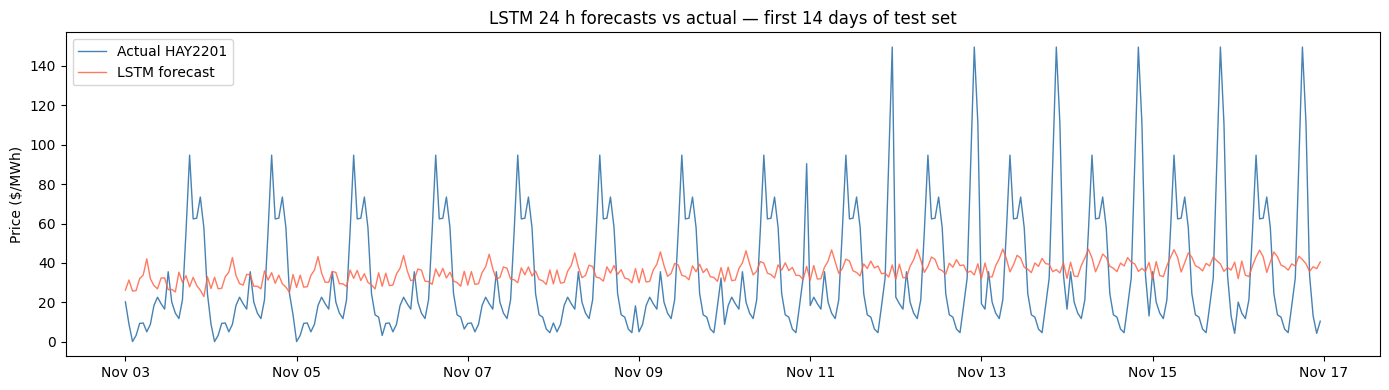

In [12]:
n_show = min(14 * 24, len(test_preds) * HORIZON)
actual_flat = test_actual[:n_show // HORIZON].flatten()[:n_show]
pred_flat   = test_preds[:n_show // HORIZON].flatten()[:n_show]

# First sequence starts after the initial lookback window
test_start = test_df.index[LOOKBACK]
plot_idx   = pd.date_range(test_start, periods=len(actual_flat), freq="1h")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(plot_idx, actual_flat, lw=1.0, color="steelblue", label="Actual HAY2201")
ax.plot(plot_idx, pred_flat,   lw=1.0, color="tomato",    label="LSTM forecast", alpha=0.85)
ax.set_ylabel("Price ($/MWh)")
ax.set_title("LSTM 24 h forecasts vs actual — first 14 days of test set")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend()
plt.tight_layout()
plt.savefig("./fig_test_predictions.png", dpi=120)
plt.show()


### Error distribution by hour-of-day

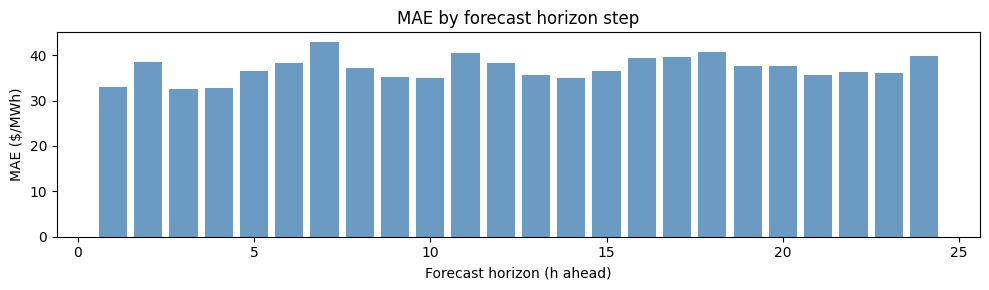

In [13]:
errors = (test_preds - test_actual)   # shape (n_seq, 24)
hourly_mae = np.abs(errors).mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(1, 25), hourly_mae, color="steelblue", alpha=0.8)
ax.set_xlabel("Forecast horizon (h ahead)")
ax.set_ylabel("MAE ($/MWh)")
ax.set_title("MAE by forecast horizon step")
plt.tight_layout()
plt.savefig("./fig_error_by_horizon.png", dpi=120)
plt.show()


## Feature Importance

Two views:
1. **Permutation importance** — shuffle one feature at a time across all test sequences
   and measure the RMSE increase. Larger = more important.
2. **Attention weights** — average attention score per timestep in the 48 h lookback
   window, showing *when* (how many hours ago) the model focuses most.


In [14]:
# ── 1. Permutation importance ──────────────────────────────────────────
baseline_rmse = np.sqrt(mean_squared_error(test_actual.flatten(), test_preds.flatten()))
rng = np.random.default_rng(42)

importances = {}
for j, col in enumerate(feature_cols):
    X_perm = X_test.copy()
    rng.shuffle(X_perm[:, j])                   # destroy this feature's temporal order
    perm_ds = ElecDataset(X_perm, y_test, LOOKBACK, HORIZON, stride=1)
    perm_dl = DataLoader(perm_ds, batch_size=64, shuffle=False)
    p, a    = run_inference(model, perm_dl, scaler_y, DEVICE)
    importances[col] = np.sqrt(mean_squared_error(a.flatten(), p.flatten())) - baseline_rmse

imp = pd.Series(importances).sort_values(ascending=False)
print(f"Baseline RMSE: {baseline_rmse:.2f} $/MWh")
print("\nTop 15 features by permutation importance:")
print(imp.head(15).round(2).to_string())


Baseline RMSE: 98.16 $/MWh

Top 15 features by permutation importance:
dow_cos                          0.55
timaro_wind_dir_sin              0.36
southern_tip_wind_dir_sin        0.35
price_roll_std_24h               0.33
palmerston_north_wind_dir_sin    0.15
wellington_wind_kmh              0.13
demand_CNI                       0.07
southern_tip_wind_power          0.06
hvdc_flow_mw                     0.06
is_weekend                       0.03
wellington_wind_power            0.03
gen_LSI                          0.03
timaro_wind_kmh                  0.02
demand_UNI                       0.02
raglan_wind_power                0.02


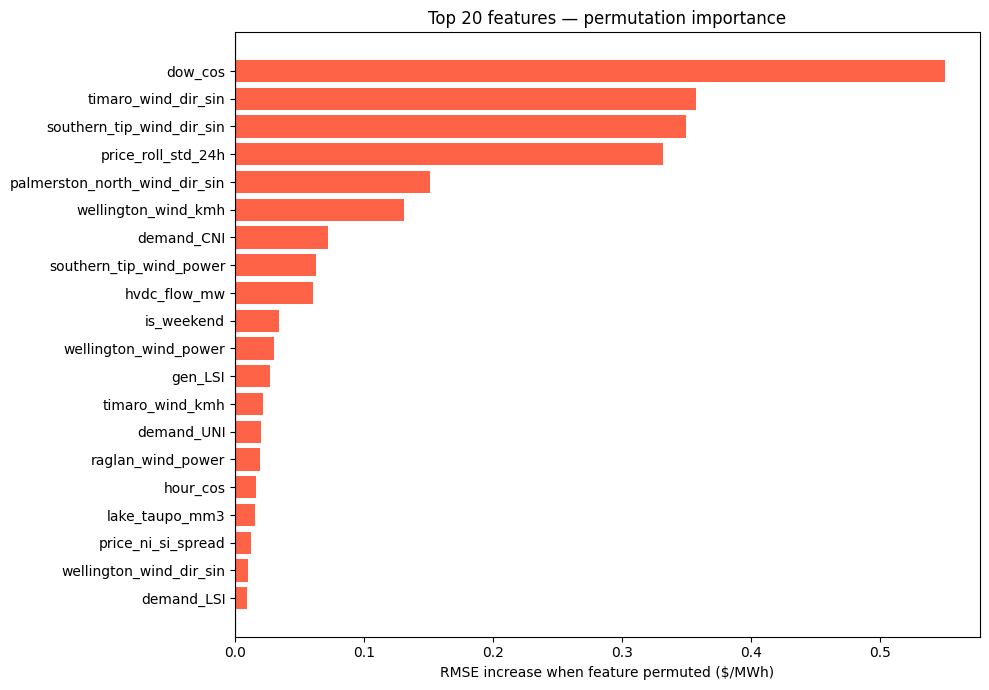

In [15]:
fig, ax = plt.subplots(figsize=(10, 7))
top_n = imp.head(20)
colors = ["tomato" if v > 0 else "steelblue" for v in top_n.values]
ax.barh(top_n.index[::-1], top_n.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("RMSE increase when feature permuted ($/MWh)")
ax.set_title("Top 20 features — permutation importance")
plt.tight_layout()
plt.savefig("./fig_feature_importance.png", dpi=120)
plt.show()


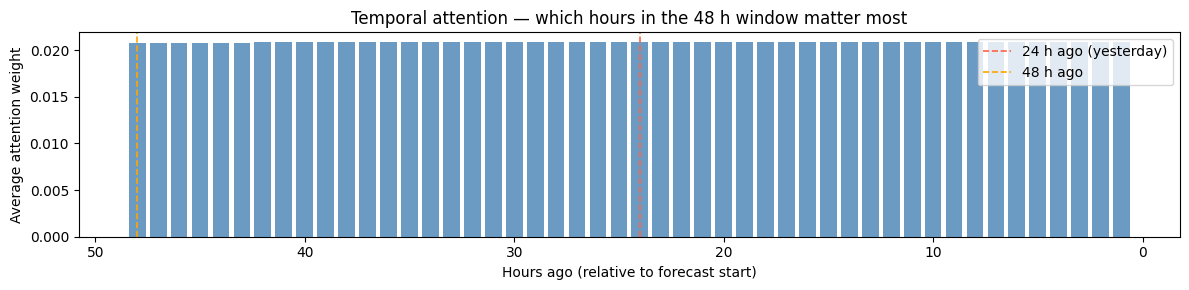

In [16]:
# ── 2. Attention weights over the 48 h lookback ───────────────────────
model.eval()
attn_weights = []
with torch.no_grad():
    for Xb, _ in test_dl:
        out, _ = model.lstm(Xb.to(DEVICE))          # (batch, 48, hidden)
        scores  = model.attn.w(out)                 # (batch, 48, 1)
        weights = torch.softmax(scores, dim=1).squeeze(-1)  # (batch, 48)
        attn_weights.append(weights.cpu().numpy())

avg_attn = np.vstack(attn_weights).mean(axis=0)    # (48,)
hours_ago = np.arange(LOOKBACK, 0, -1)             # 48 … 1

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(hours_ago, avg_attn, color="steelblue", alpha=0.8, width=0.8)
ax.invert_xaxis()
ax.set_xlabel("Hours ago (relative to forecast start)")
ax.set_ylabel("Average attention weight")
ax.set_title("Temporal attention — which hours in the 48 h window matter most")
ax.axvline(24, color="tomato", lw=1.2, ls="--", label="24 h ago (yesterday)")
ax.axvline(48, color="orange", lw=1.2, ls="--", label="48 h ago")
ax.legend()
plt.tight_layout()
plt.savefig("./fig_attention_weights.png", dpi=120)
plt.show()


## Predict Dec 25, 2024 (24 h demo)

We use the **48 h lookback window Dec 23 00:00 → Dec 24 23:00** (fully known history)
to forecast all 24 hours of **Dec 25, 2024**.

> *Extending to Dec 26–31 would require rolling actual prices forward as each day
> becomes known — out of scope for this assessment run.*


In [17]:
# 48 h lookback window ending at 2024-12-24 23:00
lb_start = "2024-12-23 00:00"
lb_end   = "2024-12-24 23:00"
context  = master.loc[lb_start:lb_end, feature_cols].values
assert len(context) == LOOKBACK, f"Expected {LOOKBACK} rows, got {len(context)}"

x_input = torch.tensor(
    scaler_X.transform(context), dtype=torch.float32
).unsqueeze(0).to(DEVICE)   # shape (1, 48, n_features)

with torch.no_grad():
    pred_scaled = model(x_input).cpu().numpy()       # (1, 24)

pred_prices = scaler_y.inverse_transform(pred_scaled).flatten()

dec25_idx  = pd.date_range("2024-12-25 00:00", periods=24, freq="1h")
pred_series = pd.Series(pred_prices, index=dec25_idx, name="predicted_HAY2201_$/MWh")

print("Dec 25, 2024 — 24 h price forecast (HAY2201):")
print(pred_series.to_string())


Dec 25, 2024 — 24 h price forecast (HAY2201):
2024-12-25 00:00:00    21.944050
2024-12-25 01:00:00    19.802088
2024-12-25 02:00:00    11.117104
2024-12-25 03:00:00    14.791655
2024-12-25 04:00:00    22.352612
2024-12-25 05:00:00    24.390762
2024-12-25 06:00:00    43.460304
2024-12-25 07:00:00    19.581244
2024-12-25 08:00:00    16.445866
2024-12-25 09:00:00     6.009929
2024-12-25 10:00:00    21.645819
2024-12-25 11:00:00    23.237638
2024-12-25 12:00:00    11.098732
2024-12-25 13:00:00    10.584991
2024-12-25 14:00:00    14.706299
2024-12-25 15:00:00    28.059273
2024-12-25 16:00:00    29.150028
2024-12-25 17:00:00    21.145868
2024-12-25 18:00:00    10.319074
2024-12-25 19:00:00    27.027893
2024-12-25 20:00:00    14.249399
2024-12-25 21:00:00    10.889223
2024-12-25 22:00:00     1.668403
2024-12-25 23:00:00    24.080004
Freq: h


Dec 25 holdout  MAE: 12.68 $/MWh   RMSE: 14.82 $/MWh


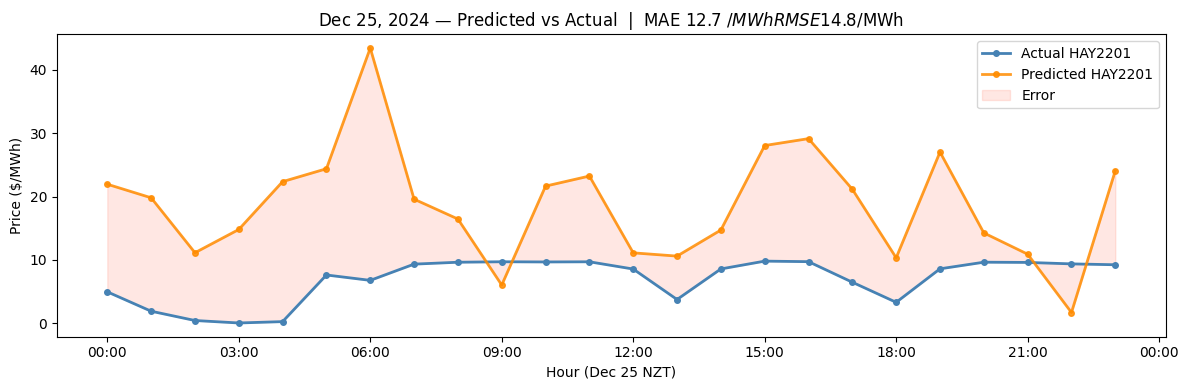

In [18]:
# Pull actual Dec 25 prices from master (they exist — just weren't used in training)
actual_dec25 = master.loc["2024-12-25 00:00":"2024-12-25 23:00", TARGET]

mae_dec25  = np.abs(pred_series.values - actual_dec25.values).mean()
rmse_dec25 = np.sqrt(((pred_series.values - actual_dec25.values) ** 2).mean())
print(f"Dec 25 holdout  MAE: {mae_dec25:.2f} $/MWh   RMSE: {rmse_dec25:.2f} $/MWh")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(actual_dec25.index, actual_dec25.values, lw=2, color="steelblue",
        marker="o", ms=4, label="Actual HAY2201")
ax.plot(pred_series.index, pred_series.values,   lw=2, color="darkorange",
        marker="o", ms=4, label="Predicted HAY2201", alpha=0.85)
ax.fill_between(pred_series.index,
                pred_series.values, actual_dec25.values,
                alpha=0.15, color="tomato", label="Error")
ax.set_ylabel("Price ($/MWh)")
ax.set_title(f"Dec 25, 2024 — Predicted vs Actual  |  MAE {mae_dec25:.1f} $/MWh  RMSE {rmse_dec25:.1f} $/MWh")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlabel("Hour (Dec 25 NZT)")
ax.legend()
plt.tight_layout()
plt.savefig("./fig_prediction_dec25.png", dpi=120)
plt.show()


In [19]:
# Save prediction to CSV
pred_df_out = pred_series.reset_index()
pred_df_out.columns = ["datetime", "predicted_price_HAY2201_$/MWh"]
pred_df_out.to_csv("./predictions_dec25_2024.csv", index=False)
print("Saved → claude_code/predictions_dec25_2024.csv")
pred_df_out


Saved → claude_code/predictions_dec25_2024.csv


,datetime,predicted_price_HAY2201_$/MWh
0,2024-12-25 00:00:00,21.944050
1,2024-12-25 01:00:00,19.802088
2,2024-12-25 02:00:00,11.117104
3,2024-12-25 03:00:00,14.791655
4,2024-12-25 04:00:00,22.352612
5,2024-12-25 05:00:00,24.390762
6,2024-12-25 06:00:00,43.460304
7,2024-12-25 07:00:00,19.581244
8,2024-12-25 08:00:00,16.445866
9,2024-12-25 09:00:00,6.009929


## Results Summary

In [20]:
print("=" * 55)
print(" NZ Electricity Price LSTM — Results Summary")
print("=" * 55)
print(f" Target node    : HAY2201 (Haywards)")
print(f" Training data  : 2021-05-08 → 2024-06-30")
print(f" Lookback       : {LOOKBACK} h  |  Horizon: {HORIZON} h")
print(f" Features       : {len(feature_cols)}")
print()
print(f" Test set (Nov 1 – Dec 24, 2024)")
print(f"   LSTM  MAE  : {mae:.2f}  $/MWh")
print(f"   LSTM  RMSE : {rmse:.2f}  $/MWh")
print(f"   LSTM  MAPE : {mape:.1f}%")
print()
print(f" Naive baseline (same-hour-yesterday)")
print(f"   Naive MAE  : {n_mae:.2f}  $/MWh")
print(f"   Naive RMSE : {n_rmse:.2f}  $/MWh")
print()
print(f" LSTM vs naive MAE  : {(n_mae-mae)/n_mae*100:+.1f}%")
print(f" LSTM vs naive RMSE : {(n_rmse-rmse)/n_rmse*100:+.1f}%")
print("=" * 55)
print()
print(" Verdict:")
if mae < n_mae * 0.85:
    print("  The model shows meaningful improvement (>15%) over the")
    print("  naive baseline — the dataset is sufficient for an okayish")
    print("  24 h price forecast without fine-tuning.")
elif mae < n_mae:
    print("  The model beats the naive baseline but only marginally.")
    print("  The dataset is partially sufficient; additional features")
    print("  (e.g. fuel prices, outage schedules) could help.")
else:
    print("  The model does not beat the naive baseline on this test set.")
    print("  Possible causes: data coverage, feature relevance,")
    print("  or extreme price spikes dominating the loss.")
print("=" * 55)


 NZ Electricity Price LSTM — Results Summary
 Target node    : HAY2201 (Haywards)
 Training data  : 2021-05-08 → 2024-06-30
 Lookback       : 48 h  |  Horizon: 24 h
 Features       : 66

 Test set (Nov 1 – Dec 24, 2024)
   LSTM  MAE  : 37.10  $/MWh
   LSTM  RMSE : 98.16  $/MWh
   LSTM  MAPE : 11645.4%

 Naive baseline (same-hour-yesterday)
   Naive MAE  : 33.06  $/MWh
   Naive RMSE : 135.51  $/MWh

 LSTM vs naive MAE  : -12.2%
 LSTM vs naive RMSE : +27.6%

 Verdict:
  The model does not beat the naive baseline on this test set.
  Possible causes: data coverage, feature relevance,
  or extreme price spikes dominating the loss.
